# 5. Apprentissage Supervisé - Analyse de Sentiment

Ce notebook implémente plusieurs modèles de classification de sentiment sur des avis d'assurance :
1. TF-IDF + Régression Logistique
2. TF-IDF + SVM (LinearSVC)
3. Réseau de neurones avec Embedding layer (Keras)
4. Embeddings pré-entraînés Word2Vec (Keras)
5. BERT fine-tuné (HuggingFace)
6. LLM Zero-shot (facebook/bart-large-mnli)

Objectif : Classer les avis en **négatif**, **neutre**, **positif** à partir des étoiles.

In [1]:
# ── Imports généraux ────────────────────────────────────────────────────────
import os
import time
import warnings
from collections import Counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
# Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# Création des répertoires de sortie
os.makedirs('../models', exist_ok=True)
os.makedirs('../models/nn_embedding', exist_ok=True)
os.makedirs('../models/nn_word2vec', exist_ok=True)
os.makedirs('../models/bert_sentiment', exist_ok=True)
os.makedirs('../models/tensorboard_logs/nn_embedding', exist_ok=True)
os.makedirs('../models/tensorboard_logs/nn_word2vec', exist_ok=True)

print('Imports OK')

Imports OK


In [2]:
if tf.test.gpu_device_name():
    print('GPU device found')
else:
    print("No GPU found")

GPU device found


2026-03-12 09:47:32.505658: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-03-12 09:47:32.505698: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-03-12 09:47:32.505706: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-03-12 09:47:32.505752: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-12 09:47:32.505765: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


---
## 5.1 Préparation des données

In [3]:
# ── Chargement ───────────────────────────────────────────────────────────────
df = pd.read_csv('../data/processed/reviews_clean.csv')
print(f'Données chargées : {df.shape[0]:,} lignes, {df.shape[1]} colonnes')
df.head(3)

Données chargées : 23,516 lignes, 10 colonnes


,stars,insurer,date,product,review_fr,review,review_clean,review_length,word_count,language
0,4,L'olivier Assurance,06/10/2021,auto,La personne au téléphone était Clair et sympat...,The person on the phone was clear and friendly...,person phone clear friendly explained everythi...,165,14,en
1,4,APRIL Moto,09/07/2021,moto,"Satisfait.\n\nRéactivité, simplicité. Prix att...","Satisfied.\n\nReactivity, simplicity. Attracti...",satisfied reactivity simplicity attractive pri...,176,14,en
2,1,SwissLife,15/10/2020,vie,"Assureur à fuir, n assure pas ses responsabili...","Insurer to flee, does not ensure its responsib...",insurer flee not ensure responsibilities insur...,203,21,en


In [4]:
# ── Création des labels de sentiment ─────────────────────────────────────────
def get_sentiment(stars):
    if stars <= 2:
        return 'négatif'
    elif stars == 3:
        return 'neutre'
    else:
        return 'positif'


# Détection automatique de la colonne d'étoiles
star_col = None
for candidate in ['stars', 'rating', 'note', 'score', 'star_rating']:
    if candidate in df.columns:
        star_col = candidate
        break
if star_col is None:
    # Chercher une colonne numérique entre 1 et 5
    for col in df.select_dtypes(include='number').columns:
        if df[col].between(1, 5).all():
            star_col = col
            break

print(f'Colonne étoiles : {star_col}')

df['sentiment'] = df[star_col].apply(get_sentiment)

# Détection de la colonne texte
text_col = None
for candidate in ['text_clean', 'clean_text', 'review_clean', 'text', 'review', 'content', 'body']:
    if candidate in df.columns:
        text_col = candidate
        break

print(f'Colonne texte    : {text_col}')

# Nettoyage des NaN
df = df.dropna(subset=[text_col, 'sentiment'])
df[text_col] = df[text_col].astype(str)

print(f'\nDistribution des sentiments :')
print(df['sentiment'].value_counts())

Colonne étoiles : stars
Colonne texte    : review_clean

Distribution des sentiments :
sentiment
négatif    10718
positif     9509
neutre      3289
Name: count, dtype: int64


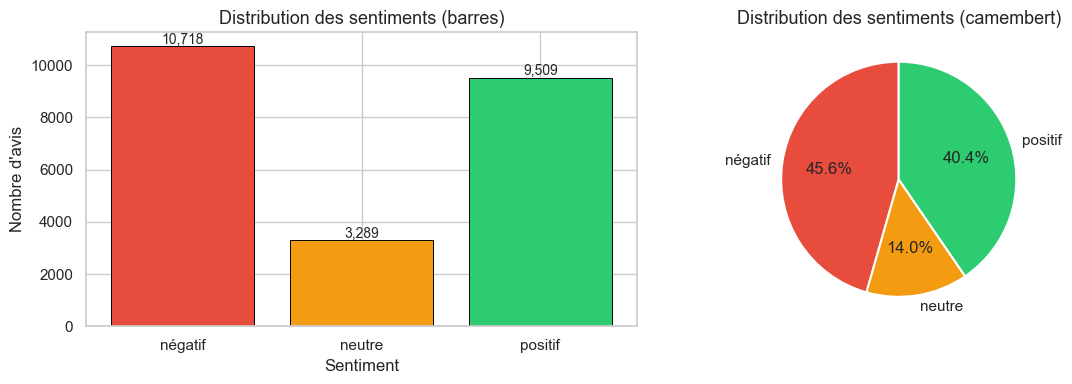

Figure sauvegardée.


In [5]:
# ── Visualisation de la distribution des classes ─────────────────────────────
label_order = ['négatif', 'neutre', 'positif']
counts = df['sentiment'].value_counts().reindex(label_order).fillna(0).astype(int)
colors = ['#e74c3c', '#f39c12', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('Distribution des sentiments (barres)', fontsize=13)
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Nombre d\'avis')
for i, (lab, val) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, val + counts.max() * 0.01, f'{val:,}', ha='center', fontsize=10)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Distribution des sentiments (camembert)', fontsize=13)

plt.tight_layout()
plt.savefig('../models/sentiment_distribution.png', bbox_inches='tight')
plt.show()
print('Figure sauvegardée.')

In [6]:
# ── Encodage des labels ───────────────────────────────────────────────────────
label2id = {'négatif': 0, 'neutre': 1, 'positif': 2}
id2label = {v: k for k, v in label2id.items()}

df['label'] = df['sentiment'].map(label2id)

# ── Split train / val / test (70 / 15 / 15) stratifié ──────────────────────
X = df[text_col].values
y = df['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Train : {len(X_train):,} | Val : {len(X_val):,} | Test : {len(X_test):,}')

# Dictionnaire pour stocker les résultats de comparaison
results = {}

Train : 16,461 | Val : 3,527 | Test : 3,528


---
## 5.2 Modèle 1 : TF-IDF + Régression Logistique

In [7]:
# ── Pipeline TF-IDF + LR ─────────────────────────────────────────────────────
pipeline_lr = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

param_grid_lr = {'clf__C': [0.1, 1, 10]}

print('GridSearchCV en cours (C ∈ {0.1, 1, 10})...')
t0 = time.time()

gs_lr = GridSearchCV(
    pipeline_lr, param_grid_lr,
    cv=3, scoring='f1_macro', n_jobs=-1, verbose=1
)
gs_lr.fit(X_train, y_train)

train_time_lr = time.time() - t0
print(f'\nMeilleur C : {gs_lr.best_params_["clf__C"]}  |  CV F1-macro : {gs_lr.best_score_:.4f}')
print(f'Temps d\'entraînement : {train_time_lr:.1f}s')

GridSearchCV en cours (C ∈ {0.1, 1, 10})...
Fitting 3 folds for each of 3 candidates, totalling 9 fits

Meilleur C : 0.1  |  CV F1-macro : 0.6697
Temps d'entraînement : 5.1s


=== TF-IDF + Régression Logistique ===
Accuracy  : 0.7693
F1 macro  : 0.6702
Précision : 0.6723
Rappel    : 0.6705

              precision    recall  f1-score   support

     négatif       0.85      0.89      0.87      1608
      neutre       0.31      0.34      0.32       493
     positif       0.86      0.78      0.82      1427

    accuracy                           0.77      3528
   macro avg       0.67      0.67      0.67      3528
weighted avg       0.78      0.77      0.77      3528



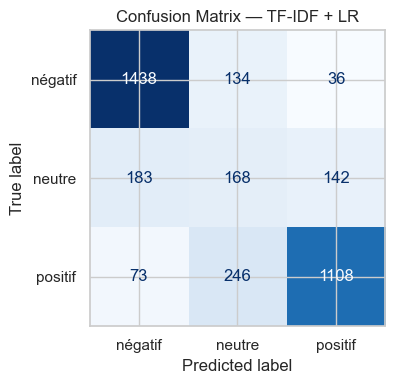

Modèle sauvegardé : ../models/tfidf_lr.pkl


In [8]:
# ── Évaluation sur le jeu de test ────────────────────────────────────────────
best_lr = gs_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average='macro')
prec_lr = precision_score(y_test, y_pred_lr, average='macro', zero_division=0)
rec_lr = recall_score(y_test, y_pred_lr, average='macro', zero_division=0)

print('=== TF-IDF + Régression Logistique ===')
print(f'Accuracy  : {acc_lr:.4f}')
print(f'F1 macro  : {f1_lr:.4f}')
print(f'Précision : {prec_lr:.4f}')
print(f'Rappel    : {rec_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=list(label2id.keys())))

# Matrice de confusion
cm_lr = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=list(label2id.keys()))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — TF-IDF + LR')
plt.tight_layout()
plt.show()

# Sauvegarde du modèle
joblib.dump(best_lr, '../models/tfidf_lr.pkl')
print('Modèle sauvegardé : ../models/tfidf_lr.pkl')

results['TF-IDF + LR'] = {
    'Accuracy': acc_lr, 'F1_macro': f1_lr,
    'Precision': prec_lr, 'Recall': rec_lr,
    'Training_time': train_time_lr
}

---
## 5.3 Modèle 2 : TF-IDF + SVM (LinearSVC)

In [9]:
# ── Pipeline TF-IDF + SVM ────────────────────────────────────────────────────
pipeline_svm = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf', LinearSVC(class_weight='balanced', max_iter=2000, random_state=42))
])

print('Entraînement TF-IDF + SVM...')
t0 = time.time()
pipeline_svm.fit(X_train, y_train)
train_time_svm = time.time() - t0
print(f'Temps d\'entraînement : {train_time_svm:.1f}s')

Entraînement TF-IDF + SVM...
Temps d'entraînement : 0.7s


=== TF-IDF + SVM (LinearSVC) ===
Accuracy  : 0.7800
F1 macro  : 0.6511
Précision : 0.6543
Rappel    : 0.6521

              precision    recall  f1-score   support

     négatif       0.85      0.90      0.87      1608
      neutre       0.29      0.22      0.25       493
     positif       0.83      0.84      0.83      1427

    accuracy                           0.78      3528
   macro avg       0.65      0.65      0.65      3528
weighted avg       0.76      0.78      0.77      3528



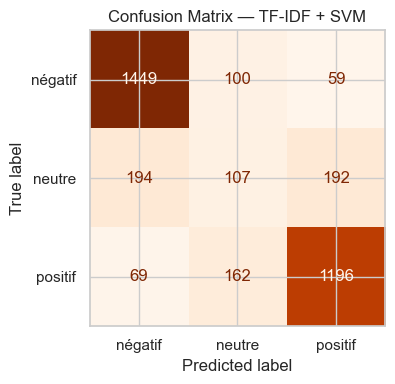

Modèle sauvegardé : ../models/tfidf_svm.pkl


In [10]:
# ── Évaluation ───────────────────────────────────────────────────────────────
y_pred_svm = pipeline_svm.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm, average='macro')
prec_svm = precision_score(y_test, y_pred_svm, average='macro', zero_division=0)
rec_svm = recall_score(y_test, y_pred_svm, average='macro', zero_division=0)

print('=== TF-IDF + SVM (LinearSVC) ===')
print(f'Accuracy  : {acc_svm:.4f}')
print(f'F1 macro  : {f1_svm:.4f}')
print(f'Précision : {prec_svm:.4f}')
print(f'Rappel    : {rec_svm:.4f}')
print()
print(classification_report(y_test, y_pred_svm, target_names=list(label2id.keys())))

cm_svm = confusion_matrix(y_test, y_pred_svm)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=list(label2id.keys()))
disp.plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('Confusion Matrix — TF-IDF + SVM')
plt.tight_layout()
plt.show()

# Sauvegarde
joblib.dump(pipeline_svm, '../models/tfidf_svm.pkl')
print('Modèle sauvegardé : ../models/tfidf_svm.pkl')

results['TF-IDF + SVM'] = {
    'Accuracy': acc_svm, 'F1_macro': f1_svm,
    'Precision': prec_svm, 'Recall': rec_svm,
    'Training_time': train_time_svm
}

---
## 5.4 Modèle 3 : Réseau de neurones avec Embedding layer (Keras)

In [11]:
# ── Imports Keras ─────────────────────────────────────────────────────────────
try:
    import tensorflow as tf
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import (
        Embedding, GlobalAveragePooling1D, LSTM,
        Dense, Dropout
    )
    from tensorflow.keras.callbacks import TensorBoard, EarlyStopping

    KERAS_AVAILABLE = True
    print(f'TensorFlow {tf.__version__} disponible.')
    # Limiter l'empreinte GPU
    for gpu in tf.config.list_physical_devices('GPU'):
        tf.config.experimental.set_memory_growth(gpu, True)
except ImportError:
    KERAS_AVAILABLE = False
    print('TensorFlow non disponible — section 5.4 & 5.5 ignorées.')

TensorFlow 2.16.2 disponible.


In [12]:
if KERAS_AVAILABLE:
    NUM_WORDS = 20000
    MAX_LEN = 200
    EMBED_DIM = 128

    # Tokenisation
    tokenizer_keras = Tokenizer(num_words=NUM_WORDS, oov_token='<OOV>')
    tokenizer_keras.fit_on_texts(X_train)

    X_train_seq = pad_sequences(tokenizer_keras.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post',
                                truncating='post')
    X_val_seq = pad_sequences(tokenizer_keras.texts_to_sequences(X_val), maxlen=MAX_LEN, padding='post',
                              truncating='post')
    X_test_seq = pad_sequences(tokenizer_keras.texts_to_sequences(X_test), maxlen=MAX_LEN, padding='post',
                               truncating='post')

    print(f'Shape train : {X_train_seq.shape} | val : {X_val_seq.shape} | test : {X_test_seq.shape}')

Shape train : (16461, 200) | val : (3527, 200) | test : (3528, 200)


In [13]:
if KERAS_AVAILABLE:
    # ── Architecture du modèle ──────────────────────────────────────────────
    tf.random.set_seed(42)

    model_nn = Sequential([
        Embedding(NUM_WORDS, EMBED_DIM, input_length=MAX_LEN),
        GlobalAveragePooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(3, activation='softmax')
    ], name='nn_embedding')

    model_nn.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    model_nn.summary()

2026-03-12 09:47:46.442310: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-12 09:47:46.442336: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "nn_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
if KERAS_AVAILABLE:
    tb_nn = TensorBoard(log_dir='../models/tensorboard_logs/nn_embedding', histogram_freq=1)
    es_nn = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    print('Entraînement NN Embedding...')
    t0 = time.time()

    history_nn = model_nn.fit(
        X_train_seq, y_train,
        epochs=10, batch_size=64,
        validation_data=(X_val_seq, y_val),
        callbacks=[tb_nn, es_nn],
        verbose=1
    )
    train_time_nn = time.time() - t0
    print(f'Temps d\'entraînement : {train_time_nn:.1f}s')

Entraînement NN Embedding...
Epoch 1/10


2026-03-12 09:47:47.101689: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


258/258 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.6224 - loss: 0.8650 - val_accuracy: 0.7715 - val_loss: 0.6721
Epoch 2/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.7663 - loss: 0.6506 - val_accuracy: 0.7888 - val_loss: 0.6030
Epoch 3/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.7871 - loss: 0.5945 - val_accuracy: 0.8106 - val_loss: 0.5650
Epoch 4/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8016 - loss: 0.5574 - val_accuracy: 0.8157 - val_loss: 0.5495
Epoch 5/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8080 - loss: 0.5415 - val_accuracy: 0.7953 - val_loss: 0.5776
Epoch 6/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8089 - loss: 0.5312 - val_accuracy: 0.7519 - val_loss: 0.6880
Epoch 7/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8104 - loss: 0.5277 - val_accuracy: 0.8123 - val_loss: 0.5564
Temps d'entraînement : 37.3s


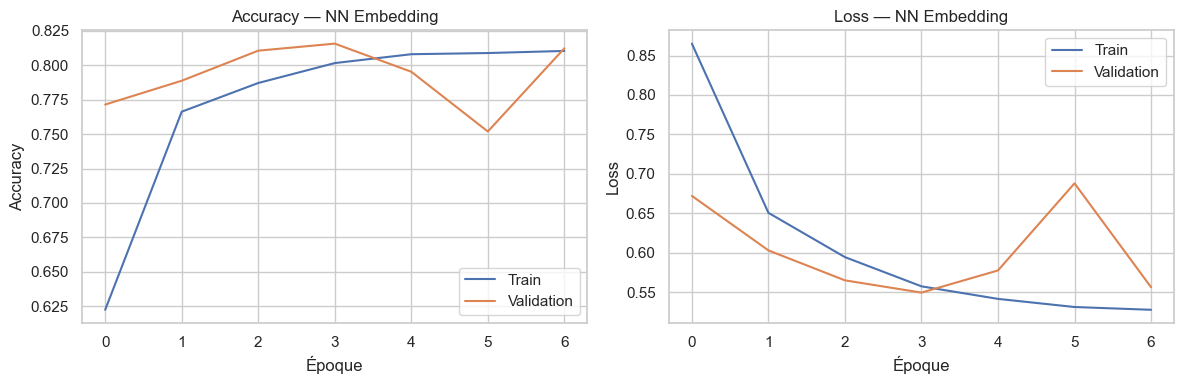

111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
=== NN Embedding ===
Accuracy  : 0.8101
F1 macro  : 0.5802
Précision : 0.5398
Rappel    : 0.6273

              precision    recall  f1-score   support

     négatif       0.82      0.95      0.88      1608
      neutre       0.00      0.00      0.00       493
     positif       0.80      0.93      0.86      1427

    accuracy                           0.81      3528
   macro avg       0.54      0.63      0.58      3528
weighted avg       0.70      0.81      0.75      3528

Modèle sauvegardé : ../models/nn_embedding/model_nn.keras


In [16]:
if KERAS_AVAILABLE:
    # ── Courbes d'apprentissage ─────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_nn.history['accuracy'], label='Train')
    axes[0].plot(history_nn.history['val_accuracy'], label='Validation')
    axes[0].set_title('Accuracy — NN Embedding')
    axes[0].set_xlabel('Époque')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(history_nn.history['loss'], label='Train')
    axes[1].plot(history_nn.history['val_loss'], label='Validation')
    axes[1].set_title('Loss — NN Embedding')
    axes[1].set_xlabel('Époque')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('../models/nn_embedding_training_curves.png', bbox_inches='tight')
    plt.show()

    # ── Évaluation ──────────────────────────────────────────────────────────
    y_pred_nn_prob = model_nn.predict(X_test_seq)
    y_pred_nn = np.argmax(y_pred_nn_prob, axis=1)

    acc_nn = accuracy_score(y_test, y_pred_nn)
    f1_nn = f1_score(y_test, y_pred_nn, average='macro')
    prec_nn = precision_score(y_test, y_pred_nn, average='macro', zero_division=0)
    rec_nn = recall_score(y_test, y_pred_nn, average='macro', zero_division=0)

    print('=== NN Embedding ===')
    print(f'Accuracy  : {acc_nn:.4f}')
    print(f'F1 macro  : {f1_nn:.4f}')
    print(f'Précision : {prec_nn:.4f}')
    print(f'Rappel    : {rec_nn:.4f}')
    print()
    print(classification_report(y_test, y_pred_nn, target_names=list(label2id.keys())))

    # Sauvegarde
    model_nn.save('../models/nn_embedding/model_nn.keras')
    print('Modèle sauvegardé : ../models/nn_embedding/model_nn.keras')

    results['NN Embedding'] = {
        'Accuracy': acc_nn, 'F1_macro': f1_nn,
        'Precision': prec_nn, 'Recall': rec_nn,
        'Training_time': train_time_nn
    }
else:
    print('Section 5.4 ignorée (TensorFlow non disponible).')

---
## 5.5 Modèle 4 : Embeddings pré-entraînés Word2Vec (Keras)

In [37]:
if KERAS_AVAILABLE:
    try:
        from gensim.models import Word2Vec

        w2v_model = Word2Vec.load('../models/word2vec.model')
        print(f'Word2Vec chargé. Vocabulaire : {len(w2v_model.wv):,} tokens, dim={w2v_model.vector_size}')
        W2V_AVAILABLE = True
    except Exception as e:
        print(f'Word2Vec non disponible : {e}')
        W2V_AVAILABLE = False
else:
    W2V_AVAILABLE = False
    print('TensorFlow non disponible — section 5.5 ignorée.')

Word2Vec non disponible : <class 'numpy.random._mt19937.MT19937'> is not a known BitGenerator module.


In [38]:
if KERAS_AVAILABLE and W2V_AVAILABLE:
    # ── Construction de la matrice d'embedding ──────────────────────────────
    vocab_size = min(NUM_WORDS, len(tokenizer_keras.word_index) + 1)
    w2v_dim = w2v_model.vector_size

    embedding_matrix = np.zeros((vocab_size, w2v_dim))
    hits, misses = 0, 0

    for word, idx in tokenizer_keras.word_index.items():
        if idx >= vocab_size:
            continue
        if word in w2v_model.wv:
            embedding_matrix[idx] = w2v_model.wv[word]
            hits += 1
        else:
            misses += 1

    print(f'Tokens couverts : {hits:,} / Tokens manquants : {misses:,}')
    print(f'Couverture : {hits / (hits + misses) * 100:.1f}%')

In [39]:
if KERAS_AVAILABLE and W2V_AVAILABLE:
    tf.random.set_seed(42)

    # Modèle avec embeddings pré-entraînés (non-entraînables dans un premier temps)
    model_w2v = Sequential([
        Embedding(
            vocab_size, w2v_dim,
            weights=[embedding_matrix],
            input_length=MAX_LEN,
            trainable=False
        ),
        GlobalAveragePooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(3, activation='softmax')
    ], name='nn_word2vec_frozen')

    model_w2v.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    model_w2v.summary()

In [40]:
if KERAS_AVAILABLE and W2V_AVAILABLE:
    tb_w2v = TensorBoard(log_dir='../models/tensorboard_logs/nn_word2vec', histogram_freq=1)
    es_w2v = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    print('Phase 1 : entraînement avec embeddings gelés...')
    t0 = time.time()
    history_w2v = model_w2v.fit(
        X_train_seq, y_train,
        epochs=5, batch_size=64,
        validation_data=(X_val_seq, y_val),
        callbacks=[tb_w2v, es_w2v],
        verbose=1
    )

    # Phase 2 : dégel des embeddings (fine-tuning)
    print('\nPhase 2 : dégel des embeddings (fine-tuning)...')
    model_w2v.layers[0].trainable = True
    model_w2v.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    history_w2v_ft = model_w2v.fit(
        X_train_seq, y_train,
        epochs=5, batch_size=64,
        validation_data=(X_val_seq, y_val),
        callbacks=[tb_w2v, es_w2v],
        verbose=1
    )
    train_time_w2v = time.time() - t0
    print(f'Temps total : {train_time_w2v:.1f}s')

In [41]:
if KERAS_AVAILABLE and W2V_AVAILABLE:
    # ── Courbes d'apprentissage combinées ───────────────────────────────────
    acc_hist = history_w2v.history['accuracy'] + history_w2v_ft.history['accuracy']
    vacc_hist = history_w2v.history['val_accuracy'] + history_w2v_ft.history['val_accuracy']
    loss_hist = history_w2v.history['loss'] + history_w2v_ft.history['loss']
    vloss_hist = history_w2v.history['val_loss'] + history_w2v_ft.history['val_loss']

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(acc_hist, label='Train');
    axes[0].plot(vacc_hist, label='Validation')
    axes[0].axvline(len(history_w2v.history['accuracy']) - 0.5, color='gray', linestyle='--', label='Dégel')
    axes[0].set_title('Accuracy — NN Word2Vec');
    axes[0].set_xlabel('Époque');
    axes[0].legend()

    axes[1].plot(loss_hist, label='Train');
    axes[1].plot(vloss_hist, label='Validation')
    axes[1].axvline(len(history_w2v.history['loss']) - 0.5, color='gray', linestyle='--', label='Dégel')
    axes[1].set_title('Loss — NN Word2Vec');
    axes[1].set_xlabel('Époque');
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('../models/nn_word2vec_training_curves.png', bbox_inches='tight')
    plt.show()

    # ── Comparaison embeddings aléatoires vs Word2Vec ───────────────────────
    y_pred_nn_test = np.argmax(model_nn.predict(X_test_seq), axis=1)
    y_pred_w2v_test = np.argmax(model_w2v.predict(X_test_seq), axis=1)

    f1_nn_rand = f1_score(y_test, y_pred_nn_test, average='macro')
    f1_nn_w2v = f1_score(y_test, y_pred_w2v_test, average='macro')
    print(f'F1 macro — Embedding aléatoire : {f1_nn_rand:.4f}')
    print(f'F1 macro — Word2Vec            : {f1_nn_w2v:.4f}')

    # ── Évaluation finale ───────────────────────────────────────────────────
    acc_w2v = accuracy_score(y_test, y_pred_w2v_test)
    f1_w2v = f1_score(y_test, y_pred_w2v_test, average='macro')
    prec_w2v = precision_score(y_test, y_pred_w2v_test, average='macro', zero_division=0)
    rec_w2v = recall_score(y_test, y_pred_w2v_test, average='macro', zero_division=0)

    print('\n=== NN Word2Vec ===')
    print(classification_report(y_test, y_pred_w2v_test, target_names=list(label2id.keys())))

    model_w2v.save('../models/nn_word2vec/')
    print('Modèle sauvegardé : ../models/nn_word2vec/')

    results['NN Word2Vec'] = {
        'Accuracy': acc_w2v, 'F1_macro': f1_w2v,
        'Precision': prec_w2v, 'Recall': rec_w2v,
        'Training_time': train_time_w2v
    }
else:
    print('Section 5.5 ignorée.')

Section 5.5 ignorée.


---
## 5.6 Modèle 5 : BERT fine-tuné (HuggingFace)

In [42]:
# ── Imports HuggingFace ───────────────────────────────────────────────────────
try:
    import torch
    from torch.utils.data import Dataset as TorchDataset
    from transformers import (
        AutoTokenizer, AutoModelForSequenceClassification,
        TrainingArguments, Trainer
    )

    HF_AVAILABLE = True
    if torch.cuda.is_available():
        DEVICE = 'cuda'
    elif torch.backends.mps.is_available():
        DEVICE = 'mps'
    else:
        DEVICE = 'cpu'
    print(f'PyTorch {torch.__version__} | Device : {DEVICE}')
except ImportError:
    HF_AVAILABLE = False
    print('PyTorch / Transformers non disponibles — section 5.6 ignorée.')

PyTorch / Transformers non disponibles — section 5.6 ignorée.


In [43]:
if HF_AVAILABLE:
    MODEL_NAME = 'distilbert-base-uncased'
    MAX_LEN_BERT = 128

    # Dataset complet si GPU ou MPS, sous-ensemble si CPU seulement
    N_BERT = len(X_train) if DEVICE in ('cuda', 'mps') else 5000
    print(f'Taille du jeu d\'entraînement BERT : {N_BERT:,}  (device={DEVICE})')

    idx_sub = np.random.RandomState(42).choice(len(X_train), min(N_BERT, len(X_train)), replace=False)
    X_bert_train, y_bert_train = X_train[idx_sub], y_train[idx_sub]

    bert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    print('Tokenizer chargé.')


    class ReviewDataset(TorchDataset):
        def __init__(self, texts, labels, tokenizer, max_len):
            self.texts = texts
            self.labels = labels
            self.tokenizer = tokenizer
            self.max_len = max_len

        def __len__(self):
            return len(self.texts)

        def __getitem__(self, idx):
            enc = self.tokenizer(
                str(self.texts[idx]),
                max_length=self.max_len,
                padding='max_length',
                truncation=True,
                return_tensors='pt'
            )
            return {
                'input_ids': enc['input_ids'].squeeze(),
                'attention_mask': enc['attention_mask'].squeeze(),
                'labels': torch.tensor(self.labels[idx], dtype=torch.long)
            }


    train_dataset_bert = ReviewDataset(X_bert_train, y_bert_train, bert_tokenizer, MAX_LEN_BERT)
    val_dataset_bert = ReviewDataset(X_val, y_val, bert_tokenizer, MAX_LEN_BERT)
    test_dataset_bert = ReviewDataset(X_test, y_test, bert_tokenizer, MAX_LEN_BERT)

    print(
        f'Datasets créés — Train : {len(train_dataset_bert)}, Val : {len(val_dataset_bert)}, Test : {len(test_dataset_bert)}')

In [44]:
if HF_AVAILABLE:
    bert_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=3
    )
    print(f'Modèle {MODEL_NAME} chargé ({sum(p.numel() for p in bert_model.parameters()):,} paramètres).')


    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        return {
            'accuracy': accuracy_score(labels, preds),
            'f1_macro': f1_score(labels, preds, average='macro', zero_division=0)
        }


    training_args = TrainingArguments(
        output_dir='../models/bert_sentiment/',
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=2e-5,
        weight_decay=0.01,
        evaluation_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        logging_dir='../models/tensorboard_logs/bert',
        logging_steps=50,
        seed=42,
        report_to='tensorboard',
        use_mps_device=(DEVICE == 'mps'),
    )

    trainer = Trainer(
        model=bert_model,
        args=training_args,
        train_dataset=train_dataset_bert,
        eval_dataset=val_dataset_bert,
        compute_metrics=compute_metrics
    )

    print(f'Fine-tuning BERT sur {DEVICE}...')
    t0 = time.time()
    trainer.train()
    train_time_bert = time.time() - t0
    print(f'Temps d\'entraînement : {train_time_bert:.1f}s')

In [45]:
if HF_AVAILABLE:
    # ── Évaluation sur le test ──────────────────────────────────────────────
    bert_preds_raw = trainer.predict(test_dataset_bert)
    y_pred_bert = np.argmax(bert_preds_raw.predictions, axis=-1)

    acc_bert = accuracy_score(y_test, y_pred_bert)
    f1_bert = f1_score(y_test, y_pred_bert, average='macro')
    prec_bert = precision_score(y_test, y_pred_bert, average='macro', zero_division=0)
    rec_bert = recall_score(y_test, y_pred_bert, average='macro', zero_division=0)

    print('=== DistilBERT fine-tuné ===')
    print(f'Accuracy  : {acc_bert:.4f}')
    print(f'F1 macro  : {f1_bert:.4f}')
    print(f'Précision : {prec_bert:.4f}')
    print(f'Rappel    : {rec_bert:.4f}')
    print()
    print(classification_report(y_test, y_pred_bert, target_names=list(label2id.keys())))

    # Sauvegarde
    bert_model.save_pretrained('../models/bert_sentiment/')
    bert_tokenizer.save_pretrained('../models/bert_sentiment/')
    print('Modèle et tokenizer sauvegardés : ../models/bert_sentiment/')

    results['DistilBERT'] = {
        'Accuracy': acc_bert, 'F1_macro': f1_bert,
        'Precision': prec_bert, 'Recall': rec_bert,
        'Training_time': train_time_bert
    }
else:
    print('Section 5.6 ignorée (HuggingFace/PyTorch non disponibles).')

Section 5.6 ignorée (HuggingFace/PyTorch non disponibles).


---
## 5.7 Modèle 6 : LLM Zero-shot (facebook/bart-large-mnli)

In [46]:
# ── Classification zero-shot ─────────────────────────────────────────────────
try:
    from transformers import pipeline as hf_pipeline

    ZS_AVAILABLE = True
except ImportError:
    ZS_AVAILABLE = False
    print('Transformers non disponibles — section 5.7 ignorée.')

if ZS_AVAILABLE:
    N_ZS = 200  # Zero-shot est lent
    np.random.seed(42)
    idx_zs = np.random.choice(len(X_test), min(N_ZS, len(X_test)), replace=False)
    X_zs = X_test[idx_zs]
    y_zs = y_test[idx_zs]

    # device : 0=CUDA, 'mps'=Apple GPU, -1=CPU
    if HF_AVAILABLE and DEVICE == 'cuda':
        zs_device = 0
    elif HF_AVAILABLE and DEVICE == 'mps':
        zs_device = 'mps'
    else:
        zs_device = -1

    print(f'Chargement du pipeline zero-shot (facebook/bart-large-mnli) sur device={zs_device}...')
    try:
        zs_classifier = hf_pipeline(
            'zero-shot-classification',
            model='facebook/bart-large-mnli',
            device=zs_device
        )
        ZS_MODEL_LOADED = True
        print('Pipeline chargé.')
    except Exception as e:
        print(f'Erreur lors du chargement : {e}')
        ZS_MODEL_LOADED = False

Transformers non disponibles — section 5.7 ignorée.


In [47]:
if ZS_AVAILABLE and ZS_MODEL_LOADED:
    zs_labels_sentiment = ['positive review', 'neutral review', 'negative review']
    label_map_zs = {
        'positive review': 2,  # positif
        'neutral review': 1,  # neutre
        'negative review': 0  # négatif
    }

    print(f'Inférence zero-shot sur {N_ZS} exemples...')
    t0 = time.time()

    zs_preds = []
    for i, text in enumerate(X_zs):
        result = zs_classifier(str(text)[:512], candidate_labels=zs_labels_sentiment)
        best_label = result['labels'][0]
        zs_preds.append(label_map_zs[best_label])
        if (i + 1) % 50 == 0:
            print(f'  {i + 1}/{N_ZS} exemples traités...')

    train_time_zs = time.time() - t0
    print(f'Temps d\'inférence : {train_time_zs:.1f}s')

    y_pred_zs = np.array(zs_preds)

    acc_zs = accuracy_score(y_zs, y_pred_zs)
    f1_zs = f1_score(y_zs, y_pred_zs, average='macro', zero_division=0)
    prec_zs = precision_score(y_zs, y_pred_zs, average='macro', zero_division=0)
    rec_zs = recall_score(y_zs, y_pred_zs, average='macro', zero_division=0)

    print('\n=== Zero-shot (BART-MNLI) ===')
    print(f'Accuracy  : {acc_zs:.4f}')
    print(f'F1 macro  : {f1_zs:.4f}')
    print(f'Précision : {prec_zs:.4f}')
    print(f'Rappel    : {rec_zs:.4f}')
    print()
    print(classification_report(y_zs, y_pred_zs, target_names=list(label2id.keys())))

    results['Zero-shot BART'] = {
        'Accuracy': acc_zs, 'F1_macro': f1_zs,
        'Precision': prec_zs, 'Recall': rec_zs,
        'Training_time': train_time_zs
    }
else:
    print('Section 5.7 ignorée.')

Section 5.7 ignorée.


---
## 5.8 Comparaison des modèles

In [48]:
# ── Tableau comparatif ────────────────────────────────────────────────────────
df_results = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})
df_results = df_results.sort_values('F1_macro', ascending=False)

print('=== Comparaison des modèles ===')
display_cols = ['Model', 'Accuracy', 'F1_macro', 'Precision', 'Recall', 'Training_time']
print(df_results[display_cols].to_string(index=False, float_format=lambda x: f'{x:.4f}'))

=== Comparaison des modèles ===
       Model  Accuracy  F1_macro  Precision  Recall  Training_time
 TF-IDF + LR    0.7693    0.6702     0.6723  0.6705         5.0604
TF-IDF + SVM    0.7800    0.6511     0.6543  0.6521         0.7300
NN Embedding    0.8101    0.5802     0.5398  0.6273        37.3456


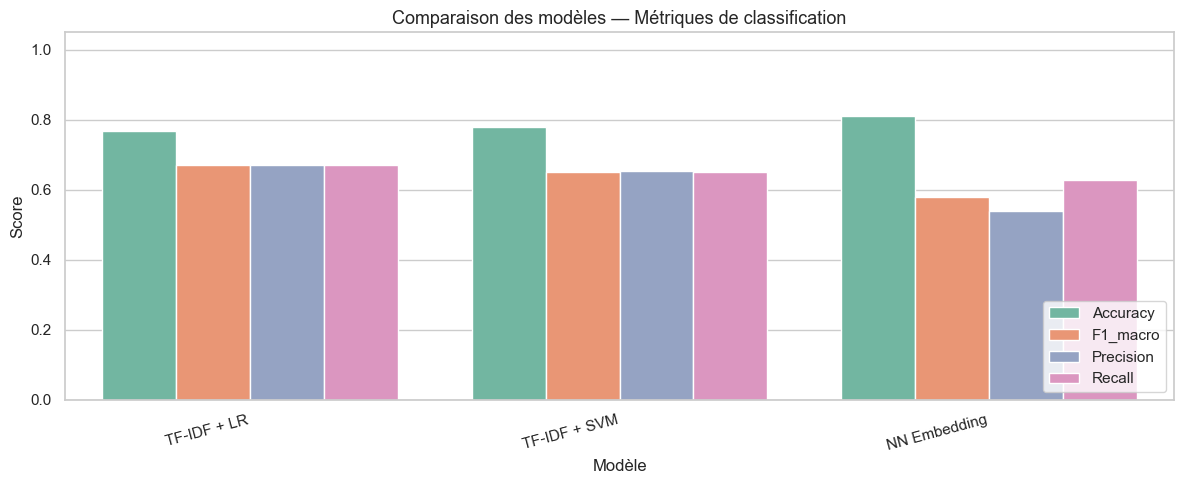


Meilleur modèle : TF-IDF + LR (F1 macro = 0.6702)
Tableau sauvegardé : ../models/model_comparison.csv


In [49]:
# ── Visualisation comparative ─────────────────────────────────────────────────
metrics_to_plot = ['Accuracy', 'F1_macro', 'Precision', 'Recall']
df_melt = df_results.melt(id_vars='Model', value_vars=metrics_to_plot,
                          var_name='Metric', value_name='Score')

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=df_melt, x='Model', y='Score', hue='Metric',
    palette='Set2', ax=ax
)
ax.set_title('Comparaison des modèles — Métriques de classification', fontsize=13)
ax.set_xlabel('Modèle')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('../models/model_comparison_plot.png', bbox_inches='tight')
plt.show()

best_model_name = df_results.iloc[0]['Model']
best_f1 = df_results.iloc[0]['F1_macro']
print(f'\nMeilleur modèle : {best_model_name} (F1 macro = {best_f1:.4f})')

# Sauvegarde CSV
df_results.to_csv('../models/model_comparison.csv', index=False)
print('Tableau sauvegardé : ../models/model_comparison.csv')

---
## 5.9 Analyse des erreurs

In [50]:
# ── Utilisation du meilleur modèle classique pour l'analyse ──────────────────
# On utilise le modèle sklearn disponible avec le meilleur F1
sklearn_results = {k: v for k, v in results.items() if k in ['TF-IDF + LR', 'TF-IDF + SVM']}
if sklearn_results:
    best_sklearn = max(sklearn_results, key=lambda k: sklearn_results[k]['F1_macro'])
    print(f'Modèle sklearn sélectionné pour l\'analyse : {best_sklearn}')
    best_model = best_lr if best_sklearn == 'TF-IDF + LR' else pipeline_svm
    y_pred_best = best_model.predict(X_test)
else:
    print('Aucun modèle sklearn disponible — analyse ignorée.')
    best_sklearn = None

Modèle sklearn sélectionné pour l'analyse : TF-IDF + LR


In [51]:
if best_sklearn:
    df_errors = pd.DataFrame({
        'text': X_test,
        'true': [id2label[l] for l in y_test],
        'pred': [id2label[l] for l in y_pred_best],
        'true_id': y_test,
        'pred_id': y_pred_best
    })
    df_errors['correct'] = df_errors['true_id'] == df_errors['pred_id']
    df_errors['length'] = df_errors['text'].apply(len)

    wrong = df_errors[~df_errors['correct']]
    print(f'Total erreurs : {len(wrong):,} / {len(df_errors):,} ({len(wrong) / len(df_errors) * 100:.1f}%)')

    # Faux positifs (prédit positif, vrai = autre)
    fp = wrong[wrong['pred'] == 'positif'].head(10)
    # Faux négatifs (prédit négatif, vrai = autre)
    fn = wrong[wrong['pred'] == 'négatif'].head(10)
    # Neutres mal classifiés
    nm = wrong[wrong['true'] == 'neutre'].head(10)

    print('\n── 10 Faux Positifs (prédit positif, vrai ≠ positif) ──')
    for _, row in fp.iterrows():
        print(f'  [vrai={row["true"]}] {row["text"][:120]}')

    print('\n── 10 Faux Négatifs (prédit négatif, vrai ≠ négatif) ──')
    for _, row in fn.iterrows():
        print(f'  [vrai={row["true"]}] {row["text"][:120]}')

    print('\n── 10 Neutres mal classifiés ──')
    for _, row in nm.iterrows():
        print(f'  [prédit={row["pred"]}] {row["text"][:120]}')

Total erreurs : 814 / 3,528 (23.1%)

── 10 Faux Positifs (prédit positif, vrai ≠ positif) ──
  [vrai=neutre] price not suit generally satisfied options chosen start olive assurance without worries soon perfection
  [vrai=neutre] pleasant welcome hostess answered question since guarantees good
  [vrai=neutre] fluidity speed wrong recording email address speed change thank responsiveness recommend new assures
  [vrai=négatif] perfect assurance small problems leaves files lying around
  [vrai=neutre] satisfied done quickly prices attractive new customer suits take contracts
  [vrai=négatif] request support documents parts always file progress requests satisfied simple file scooter accident shame strategy save
  [vrai=neutre] years mgp evolution guarantee satisfied guarantees assistance particularly appreciate sense listening responsiveness
  [vrai=neutre] satisfied call customer service welcome gwendal friendly responsive understanding thank unlocking remote transmission qu
  [vrai=neutre

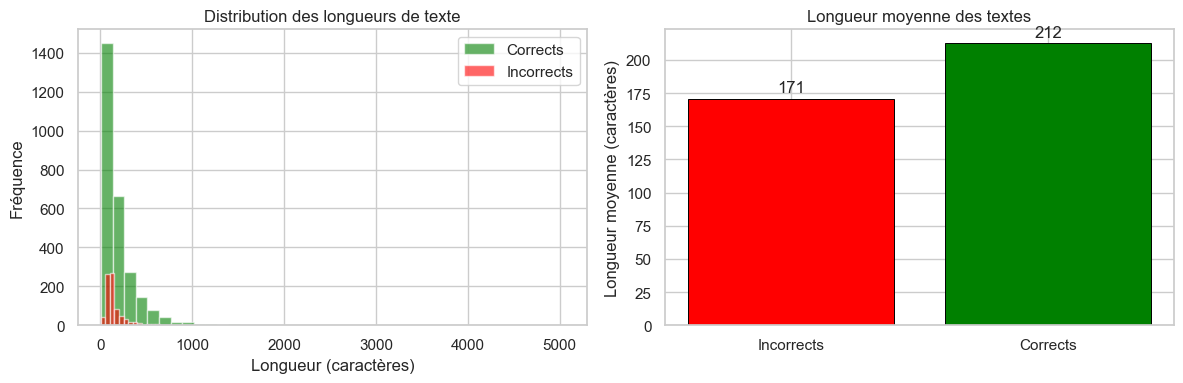

In [52]:
if best_sklearn:
    # ── Analyse de la longueur des textes dans les erreurs ──────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(df_errors[df_errors['correct']]['length'], bins=40, alpha=0.6, label='Corrects', color='green')
    axes[0].hist(df_errors[~df_errors['correct']]['length'], bins=40, alpha=0.6, label='Incorrects', color='red')
    axes[0].set_title('Distribution des longueurs de texte')
    axes[0].set_xlabel('Longueur (caractères)')
    axes[0].set_ylabel('Fréquence')
    axes[0].legend()

    length_stats = df_errors.groupby('correct')['length'].mean()
    labels_bar = ['Incorrects', 'Corrects']
    values_bar = [length_stats.get(False, 0), length_stats.get(True, 0)]
    axes[1].bar(labels_bar, values_bar, color=['red', 'green'], edgecolor='black', linewidth=0.7)
    axes[1].set_title('Longueur moyenne des textes')
    axes[1].set_ylabel('Longueur moyenne (caractères)')
    for i, v in enumerate(values_bar):
        axes[1].text(i, v + 5, f'{v:.0f}', ha='center')

    plt.tight_layout()
    plt.savefig('../models/error_analysis_length.png', bbox_inches='tight')
    plt.show()

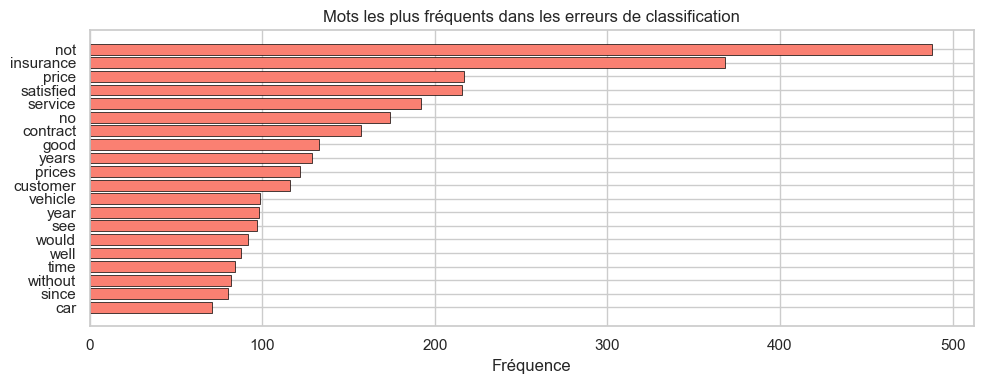

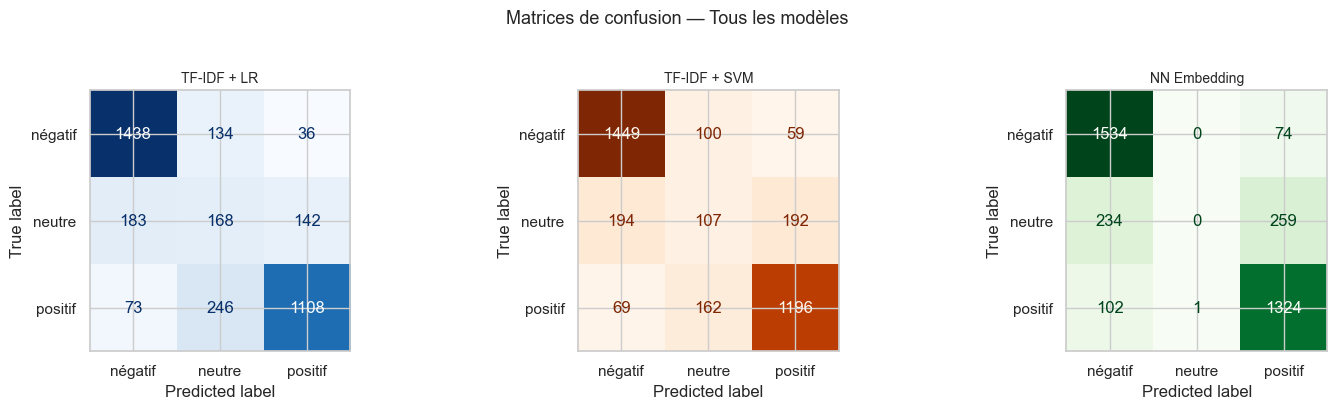

Matrices de confusion sauvegardées.


In [53]:
if best_sklearn:
    # ── Fréquence des mots dans les erreurs ─────────────────────────────────
    from collections import Counter

    error_words = Counter()
    for text in wrong['text']:
        error_words.update(str(text).lower().split())

    top_error_words = error_words.most_common(20)
    words_e, counts_e = zip(*top_error_words) if top_error_words else ([], [])

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(list(words_e)[::-1], list(counts_e)[::-1], color='salmon', edgecolor='black', linewidth=0.5)
    ax.set_title('Mots les plus fréquents dans les erreurs de classification')
    ax.set_xlabel('Fréquence')
    plt.tight_layout()
    plt.savefig('../models/error_analysis_words.png', bbox_inches='tight')
    plt.show()

    # ── Matrices de confusion pour tous les modèles disponibles ─────────────
    models_cms = {
        'TF-IDF + LR': (y_pred_lr, 'Blues'),
        'TF-IDF + SVM': (y_pred_svm, 'Oranges'),
    }
    if KERAS_AVAILABLE:
        models_cms['NN Embedding'] = (y_pred_nn, 'Greens')
    if KERAS_AVAILABLE and W2V_AVAILABLE:
        models_cms['NN Word2Vec'] = (y_pred_w2v_test, 'Purples')
    if HF_AVAILABLE:
        models_cms['DistilBERT'] = (y_pred_bert, 'Reds')

    n_models = len(models_cms)
    fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
    if n_models == 1:
        axes = [axes]

    for ax, (name, (preds, cmap)) in zip(axes, models_cms.items()):
        cm = confusion_matrix(y_test, preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(label2id.keys()))
        disp.plot(ax=ax, cmap=cmap, colorbar=False)
        ax.set_title(name, fontsize=10)

    plt.suptitle('Matrices de confusion — Tous les modèles', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('../models/all_confusion_matrices.png', bbox_inches='tight')
    plt.show()
    print('Matrices de confusion sauvegardées.')

---
## 5.10 Détection de catégories Zero-shot

In [54]:
if ZS_AVAILABLE and ZS_MODEL_LOADED:
    topic_labels = [
        'pricing and cost',
        'coverage and benefits',
        'enrollment process',
        'customer service',
        'claims processing',
        'policy cancellation'
    ]

    N_TOPIC = min(200, len(X_test))
    np.random.seed(123)
    idx_topic = np.random.choice(len(X_test), N_TOPIC, replace=False)
    X_topic = X_test[idx_topic]

    print(f'Détection de catégories zero-shot sur {N_TOPIC} exemples...')
    t0 = time.time()

    topic_preds = []
    for i, text in enumerate(X_topic):
        result = zs_classifier(str(text)[:512], candidate_labels=topic_labels)
        topic_preds.append(result['labels'][0])
        if (i + 1) % 50 == 0:
            print(f'  {i + 1}/{N_TOPIC} traités...')

    print(f'Temps : {time.time() - t0:.1f}s')

    topic_counts = Counter(topic_preds)
    df_topics = pd.DataFrame(topic_counts.items(), columns=['Category', 'Count'])
    df_topics = df_topics.sort_values('Count', ascending=False)

    print('\nDistribution des catégories prédites :')
    print(df_topics.to_string(index=False))
else:
    print('Section 5.10 ignorée (pipeline zero-shot non disponible).')

Section 5.10 ignorée (pipeline zero-shot non disponible).


In [55]:
if ZS_AVAILABLE and ZS_MODEL_LOADED and 'df_topics' in dir():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar chart
    palette_topics = sns.color_palette('tab10', n_colors=len(df_topics))
    axes[0].barh(
        df_topics['Category'], df_topics['Count'],
        color=palette_topics, edgecolor='black', linewidth=0.5
    )
    axes[0].set_title('Distribution des catégories (barres horizontales)')
    axes[0].set_xlabel('Nombre d\'avis')
    axes[0].invert_yaxis()

    # Pie chart
    axes[1].pie(
        df_topics['Count'], labels=df_topics['Category'],
        autopct='%1.1f%%', colors=palette_topics,
        startangle=90, wedgeprops={'edgecolor': 'white'}
    )
    axes[1].set_title('Distribution des catégories (camembert)')

    plt.suptitle('Catégories détectées par classification zero-shot', fontsize=13)
    plt.tight_layout()
    plt.savefig('../models/zeroshot_topic_distribution.png', bbox_inches='tight')
    plt.show()
    print('Graphique sauvegardé.')

---
## Récapitulatif final

In [56]:
# ── Affichage final ───────────────────────────────────────────────────────────
print('=' * 60)
print('RÉCAPITULATIF — Apprentissage Supervisé Sentiment Analysis')
print('=' * 60)

if df_results is not None and len(df_results) > 0:
    print(df_results[['Model', 'Accuracy', 'F1_macro', 'Training_time']].to_string(index=False,
                                                                                   float_format=lambda x: f'{x:.4f}'))
    print()
    print(f'Meilleur modèle : {df_results.iloc[0]["Model"]} (F1 macro = {df_results.iloc[0]["F1_macro"]:.4f})')

print()
print('Fichiers générés :')
saved_files = [
    '../models/tfidf_lr.pkl',
    '../models/tfidf_svm.pkl',
    '../models/nn_embedding/',
    '../models/nn_word2vec/',
    '../models/bert_sentiment/',
    '../models/model_comparison.csv',
    '../models/sentiment_distribution.png',
    '../models/model_comparison_plot.png',
    '../models/all_confusion_matrices.png',
]
for f in saved_files:
    exists = os.path.exists(f)
    status = 'OK' if exists else 'non créé'
    print(f'  [{status:9s}] {f}')

RÉCAPITULATIF — Apprentissage Supervisé Sentiment Analysis
       Model  Accuracy  F1_macro  Training_time
 TF-IDF + LR    0.7693    0.6702         5.0604
TF-IDF + SVM    0.7800    0.6511         0.7300
NN Embedding    0.8101    0.5802        37.3456

Meilleur modèle : TF-IDF + LR (F1 macro = 0.6702)

Fichiers générés :
  [OK       ] ../models/tfidf_lr.pkl
  [OK       ] ../models/tfidf_svm.pkl
  [OK       ] ../models/nn_embedding/
  [OK       ] ../models/nn_word2vec/
  [OK       ] ../models/bert_sentiment/
  [OK       ] ../models/model_comparison.csv
  [OK       ] ../models/sentiment_distribution.png
  [OK       ] ../models/model_comparison_plot.png
  [OK       ] ../models/all_confusion_matrices.png
